In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import sklearn.model_selection as model_selection

In [10]:
X,y=make_blobs(n_samples=1000, n_features=3, centers=3, random_state=0)

In [11]:
X

array([[-0.33037079,  7.5366206 ,  8.66994409],
       [-1.29255396,  8.60089782,  8.30640611],
       [ 0.58945247, -1.93484754,  3.51999917],
       ...,
       [ 1.33842164,  3.89029126,  3.59565643],
       [-0.25432304,  2.34551572,  1.53730484],
       [ 0.72885503,  5.89584567,  2.61818752]], shape=(1000, 3))

In [12]:
y

array([2, 2, 1, 0, 2, 1, 1, 2, 2, 2, 0, 1, 1, 2, 2, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 2, 0, 1, 1, 2, 2, 0, 2, 1, 2, 0, 0, 2, 2, 2, 2, 0, 2, 1,
       1, 2, 0, 0, 2, 0, 2, 0, 2, 2, 0, 1, 1, 1, 1, 1, 2, 0, 1, 0, 0, 2,
       1, 0, 2, 2, 0, 2, 1, 2, 1, 2, 0, 2, 1, 0, 0, 1, 1, 0, 1, 2, 2, 2,
       2, 0, 2, 2, 2, 1, 2, 1, 0, 2, 0, 2, 2, 1, 0, 2, 0, 1, 2, 0, 0, 1,
       0, 0, 0, 2, 0, 2, 0, 2, 2, 2, 2, 1, 1, 0, 0, 2, 2, 0, 2, 2, 0, 2,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 2, 1, 2, 1, 2, 0, 1, 2, 1, 2, 0, 2, 1,
       1, 0, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0, 0, 1, 1, 2, 0, 1, 0, 1, 1, 0,
       2, 1, 1, 0, 0, 0, 0, 0, 2, 2, 1, 2, 2, 1, 1, 0, 2, 2, 1, 1, 2, 1,
       2, 0, 0, 0, 2, 1, 0, 1, 1, 0, 0, 0, 2, 1, 1, 2, 2, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 1, 0, 0, 0,
       2, 2, 1, 1, 1, 0, 2, 0, 0, 0, 0, 2, 1, 0, 1, 1, 1, 0, 2, 2, 0, 0,
       2, 0, 2, 0, 1, 2, 0, 2, 0, 1, 1, 0, 1, 1, 1, 1, 2, 0, 1, 2, 1, 1,
       1, 2, 0, 0, 1, 0, 2, 1, 0, 2, 2, 1, 2, 2, 1,

In [13]:
X.shape

(1000, 3)

In [14]:
y.shape

(1000,)

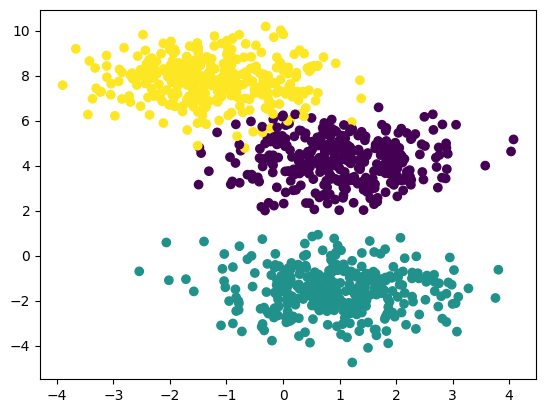

In [15]:
plt.scatter(X[:,0],X[:,1],c=y)

In [17]:
##standrdization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [20]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [21]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=0)

In [22]:
kmeans.fit(X_train_scaled)

KMeans(n_clusters=3, random_state=0)

In [23]:
y_train_pred=kmeans.predict(X_train_scaled)
y_test_pred=kmeans.predict(X_test_scaled)

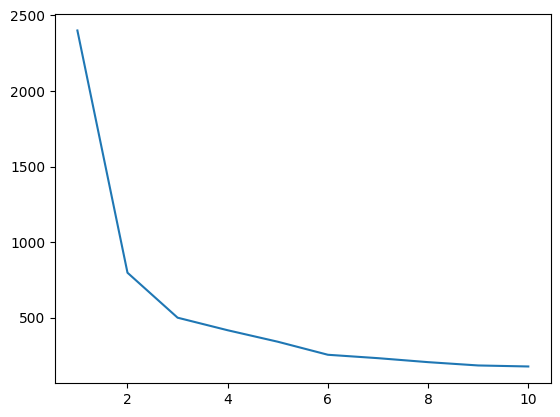

In [24]:
#Elbow method to find k
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=0)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)

In [25]:
## plot model performance
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train,y_train_pred))
print(accuracy_score(y_test,y_test_pred))

0.33
0.345


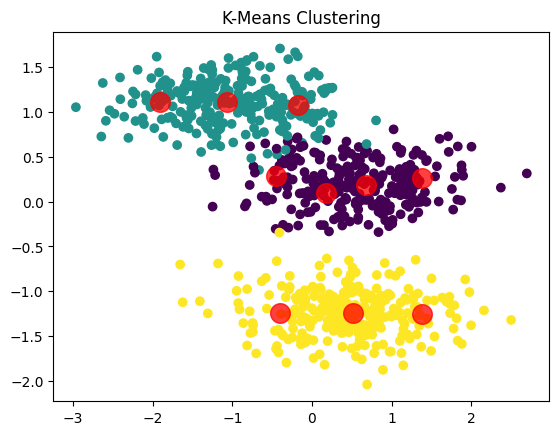

In [31]:
#plot the clusters
plt.scatter(X_train_scaled[:,0],X_train_scaled[:,1],c=y_train_pred)
# plot culsters with centroids
centroids=kmeans.cluster_centers_
plt.scatter(centroids[:,0],centroids[:,1],c='red',s=200,alpha=0.75)
plt.title('K-Means Clustering')
plt.show()

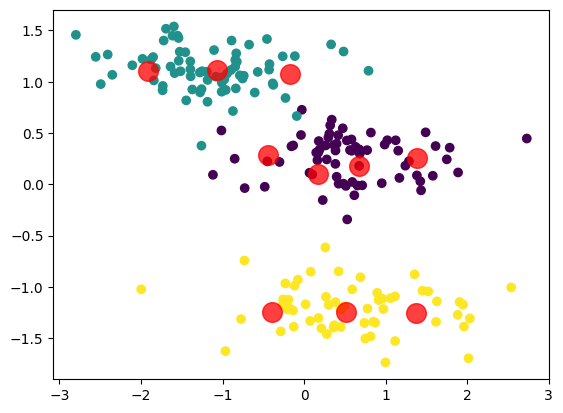

In [32]:
plt.scatter(X_test_scaled[:,0],X_test_scaled[:,1],c=y_test_pred)
plt.scatter(centroids[:,0],centroids[:,1],c='red',s=200,alpha=0.75)

In [33]:
#### validation
from sklearn.metrics import silhouette_score
silhouette_score(X_train_scaled,y_train_pred)

np.float64(0.5197194726804409)

In [35]:
## kneeloctor
!pip install kneed
from kneed import KneeLocator
import matplotlib.pyplot as plt
import numpy as np      
import pandas as pd




[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
kl = KneeLocator(range(1, 11), wcss,curve='convex', direction='decreasing')

In [44]:
kl.elbow , kl.knee_y

(np.int64(3), np.float64(500.6811346439306))